# Component Summation

Aggregate projections from the six per-component notebooks into total GMSL.

**Components:** Thermosteric (ocean), Glaciers, Greenland, EAIS, Antarctic Peninsula, WAIS

**Method:** Load MC sample ensembles from `component_results.h5`, sum sample-by-sample to preserve correlations within each draw, then compute percentiles on the total.

**Sections:**
0. Imports & configuration
1. Load all component projections
2. Sum components → total GMSL
3. Summary table (2050, 2100, 2150)
4. Projection fan plots
5. Component stack & variance decomposition
6. IPCC AR6 comparison

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.style.use('seaborn-v0_8-poster')

sys.path.insert(0, '.')
from component_io import (
    load_all_projections, load_component, list_components,
    PROJ_SSPS, PROJ_YEARS, DEFAULT_H5_PATH,
)
from component_projections import (
    read_ipcc_component_nc, ipcc_extract,
    get_our_stats, get_ipcc_stats, stats_dict,
)
from component_analysis import compute_variance_fractions
from component_plotting import (
    SSP_COLORS, COMP_COLORS, M_TO_MM,
    plot_component_projections,
    plot_variance_decomposition,
)

RAW_DIR = '../data/raw'
FIG_DIR = '../figures'
CONF_BASE = f'{RAW_DIR}/ipcc_ar6/slr/ar6/global/confidence_output_files'

# Display names for components (HDF5 key → label)
COMP_LABELS = {
    'ocean': 'Thermosteric',
    'glacier': 'Glaciers',
    'greenland': 'Greenland',
    'eais': 'EAIS',
    'apeninsula': 'Peninsula',
    'wais': 'WAIS',
    'tws': 'TWS',
}

# SSP name → IPCC code
SSP_TO_CODE = {
    'SSP1-2.6': 'ssp126', 'SSP2-4.5': 'ssp245',
    'SSP3-7.0': 'ssp370', 'SSP5-8.5': 'ssp585',
}

## 1. Load All Component Projections

In [2]:
# Inventory
list_components()

File: /Users/minchew/Dropbox/Documents/Research/SLR/forecasting/global_simple_v1/slr_forecast/data/processed/component_results.h5
  Baseline year: 2005.0
  N samples: 2000
  Proj years: 1950–2150

  apeninsula
    model: linear_dols
    SSPs: SSP1-2.6, SSP2-4.5, SSP3-7.0, SSP5-8.5
    full samples: True
    saved: 2026-03-25T05:06:35.511507+00:00
  eais
    model: trend_only
    SSPs: SSP1-2.6, SSP2-4.5, SSP3-7.0, SSP5-8.5
    full samples: True
    saved: 2026-03-25T05:06:50.957673+00:00
  glacier
    model: linear_dols
    SSPs: SSP1-2.6, SSP2-4.5, SSP3-7.0, SSP5-8.5
    full samples: True
    saved: 2026-03-25T03:04:41.065533+00:00
  greenland
    model: smb_literature_plus_discharge_ode
    SSPs: SSP1-2.6, SSP2-4.5, SSP3-7.0, SSP5-8.5
    full samples: True
    saved: 2026-03-25T01:52:24.776795+00:00
  ocean
    model: physical_1layer_joint
    SSPs: SSP1-2.6, SSP2-4.5, SSP3-7.0, SSP5-8.5
    full samples: True
    saved: 2026-03-27T00:04:24.414939+00:00
  wais
    model: a4_deep_u

['apeninsula', 'eais', 'glacier', 'greenland', 'ocean', 'wais']

In [3]:
# Load projection ensembles for all components
proj_years, all_proj = load_all_projections()

available = sorted(all_proj.keys())
print(f'Loaded components: {available}')
print(f'Projection years: {proj_years[0]:.0f}–{proj_years[-1]:.0f} ({len(proj_years)} pts)')

# Check SSP coverage per component
for comp in available:
    ssps = sorted(all_proj[comp].keys())
    has_samples = all('samples' in all_proj[comp][s] for s in ssps)
    print(f'  {comp:12s}  SSPs: {", ".join(ssps)}  samples: {has_samples}')

Loaded components: ['apeninsula', 'eais', 'glacier', 'greenland', 'ocean', 'wais']
Projection years: 1950–2150 (201 pts)
  apeninsula    SSPs: SSP1-2.6, SSP2-4.5, SSP3-7.0, SSP5-8.5  samples: True
  eais          SSPs: SSP1-2.6, SSP2-4.5, SSP3-7.0, SSP5-8.5  samples: True
  glacier       SSPs: SSP1-2.6, SSP2-4.5, SSP3-7.0, SSP5-8.5  samples: True
  greenland     SSPs: SSP1-2.6, SSP2-4.5, SSP3-7.0, SSP5-8.5  samples: True
  ocean         SSPs: SSP1-2.6, SSP2-4.5, SSP3-7.0, SSP5-8.5  samples: True
  wais          SSPs: SSP1-2.6, SSP2-4.5, SSP3-7.0, SSP5-8.5  samples: True


In [4]:
# ── Load IPCC TWS (land water storage) and generate synthetic MC samples ──
# TWS is not modeled independently; we adopt the IPCC AR6 projections
# directly.  IPCC provides quantiles, so we fit a normal distribution
# at each time step and draw N_SAMPLES to enable sample-level summation.

from component_io import N_SAMPLES

tws_proj = {}
for ssp in PROJ_SSPS:
    code = SSP_TO_CODE[ssp]
    data = read_ipcc_component_nc(CONF_BASE, 'medium_confidence', code,
                                  'landwaterstorage')
    if data is None:
        print(f'  TWS: {ssp} not found — skipping')
        continue

    ie = ipcc_extract(data, quantiles_target=(0.05, 0.17, 0.5, 0.83, 0.95))
    ipcc_years = ie['years']
    q50 = ie['q50']           # mm
    q05 = ie['q05']
    q95 = ie['q95']
    q17 = ie['q17']
    q83 = ie['q83']

    # Approximate sigma from 90% CI: (q95 - q05) / (2 * 1.645)
    sigma_mm = (q95 - q05) / (2 * 1.645)
    sigma_mm = np.maximum(sigma_mm, 0.1)  # floor to avoid zero

    # Draw MC samples at IPCC time points, then interpolate onto PROJ_YEARS
    rng_tws = np.random.default_rng(seed=777)
    n_ipcc = len(ipcc_years)
    raw_samples_mm = np.zeros((N_SAMPLES, n_ipcc))
    for j in range(n_ipcc):
        raw_samples_mm[:, j] = rng_tws.normal(q50[j], sigma_mm[j], N_SAMPLES)

    # Interpolate onto PROJ_YEARS (meters); IPCC starts at 2005
    samples_m = np.zeros((N_SAMPLES, len(PROJ_YEARS)))
    for i in range(N_SAMPLES):
        samples_m[i] = np.interp(PROJ_YEARS, ipcc_years,
                                  raw_samples_mm[i] / M_TO_MM)

    tws_proj[ssp] = {
        'samples': samples_m,
        'median': np.median(samples_m, axis=0),
        'p5': np.percentile(samples_m, 5, axis=0),
        'p17': np.percentile(samples_m, 17, axis=0),
        'p83': np.percentile(samples_m, 83, axis=0),
        'p95': np.percentile(samples_m, 95, axis=0),
    }

# Inject into all_proj so it participates in the standard summation
all_proj['tws'] = tws_proj

idx_2100 = np.argmin(np.abs(PROJ_YEARS - 2100))
for ssp in PROJ_SSPS:
    if ssp in tws_proj:
        med = tws_proj[ssp]['median'][idx_2100] * M_TO_MM
        lo = tws_proj[ssp]['p5'][idx_2100] * M_TO_MM
        hi = tws_proj[ssp]['p95'][idx_2100] * M_TO_MM
        print(f'  TWS {ssp} at 2100: {med:.0f} [{lo:.0f}, {hi:.0f}] mm')

  TWS SSP1-2.6 at 2100: 29 [8, 50] mm
  TWS SSP2-4.5 at 2100: 30 [7, 53] mm
  TWS SSP3-7.0 at 2100: 35 [9, 61] mm
  TWS SSP5-8.5 at 2100: 29 [8, 50] mm


## 2. Sum Components → Total GMSL

Sum sample-by-sample across components to propagate uncertainty correctly. Each MC draw $i$ gives one total trajectory:

$$H_{\mathrm{total}}^{(i)}(t) = \sum_{c} H_c^{(i)}(t)$$

Percentiles are then computed across the ensemble of total trajectories.

In [5]:
# ── Build comp_projections in the {ssp: {Label: dict}} layout ──
# This is the format expected by plot_component_projections and
# compute_variance_fractions.
comp_projections = {}

for ssp in PROJ_SSPS:
    comp_projections[ssp] = {}

    # Per-component entries (relabelled)
    for hdf_key, label in COMP_LABELS.items():
        if hdf_key in all_proj and ssp in all_proj[hdf_key]:
            comp_projections[ssp][label] = all_proj[hdf_key][ssp]

    # Total: sum MC samples across all available components
    n_samples = None
    total_samples = np.zeros((1, len(proj_years)))  # placeholder shape
    n_comps_summed = 0
    for hdf_key in COMP_LABELS:
        if hdf_key not in all_proj or ssp not in all_proj[hdf_key]:
            continue
        s = all_proj[hdf_key][ssp]['samples']
        if n_samples is None:
            n_samples = s.shape[0]
            total_samples = np.zeros((n_samples, len(proj_years)))
        total_samples += s
        n_comps_summed += 1

    comp_projections[ssp]['Total_sum'] = {
        'samples': total_samples,
        'median': np.median(total_samples, axis=0),
        'p5': np.percentile(total_samples, 5, axis=0),
        'p17': np.percentile(total_samples, 17, axis=0),
        'p83': np.percentile(total_samples, 83, axis=0),
        'p95': np.percentile(total_samples, 95, axis=0),
    }

print(f'Summed {n_comps_summed} components for each SSP')
print(f'Total samples shape: {total_samples.shape}')

Summed 7 components for each SSP
Total samples shape: (2000, 201)


## 3. Summary Table (2050, 2100, 2150)

In [6]:
# ── Summary table: per-component + total at milestone years ──
milestone_years = [2050, 2100, 2150]
comp_order = ['Thermosteric', 'Glaciers', 'Greenland', 'EAIS', 'Peninsula', 'WAIS', 'TWS']

rows = []
for ssp in PROJ_SSPS:
    for yr in milestone_years:
        idx = np.argmin(np.abs(proj_years - yr))
        row = {'SSP': ssp, 'Year': yr}
        for cname in comp_order:
            if cname in comp_projections[ssp]:
                s = comp_projections[ssp][cname]['samples'][:, idx] * M_TO_MM
                row[cname] = f'{np.median(s):.0f} [{np.percentile(s, 5):.0f}, {np.percentile(s, 95):.0f}]'
            else:
                row[cname] = '—'
        s_tot = comp_projections[ssp]['Total_sum']['samples'][:, idx] * M_TO_MM
        row['Total'] = f'{np.median(s_tot):.0f} [{np.percentile(s_tot, 5):.0f}, {np.percentile(s_tot, 95):.0f}]'
        rows.append(row)

df_summary = pd.DataFrame(rows)
df_summary = df_summary.set_index(['SSP', 'Year'])
display(df_summary)

Thermosteric        Glaciers       Greenland  \
SSP      Year                                                    
SSP1-2.6 2050      53 [47, 60]     45 [42, 48]     29 [18, 40]   
         2100      63 [52, 77]   104 [97, 111]    82 [50, 112]   
         2150      53 [40, 67]   104 [97, 111]   116 [66, 165]   
SSP2-4.5 2050      63 [56, 70]     46 [43, 49]     31 [19, 43]   
         2100   147 [125, 173]  125 [116, 134]   120 [72, 166]   
         2150   214 [179, 257]  125 [116, 134]  204 [110, 294]   
SSP3-7.0 2050      71 [63, 78]     47 [44, 50]     33 [20, 45]   
         2100   274 [227, 319]  145 [133, 155]   160 [94, 224]   
         2150   613 [492, 736]  145 [133, 155]  319 [167, 470]   
SSP5-8.5 2050      86 [76, 95]     49 [46, 53]     37 [22, 51]   
         2100   394 [322, 461]  164 [150, 176]  206 [117, 293]   
         2150  917 [725, 1109]  164 [150, 176]  427 [212, 645]   

                         EAIS   Peninsula            WAIS           TWS  \
SSP      Year                                                             
SSP1-2.6 2050     -5 [-7, -2]    3 [2, 4]    99 [26, 445]    9 [-1, 19]   
         2100   -13 [-20, -6]   7 [4, 11]  397 [67, 1919]    29 [8, 50]   
         2150  -22 [-33, -10]   7 [4, 11]  851 [94, 4743]   45 [16, 73]   
SSP2-4.5 2050     -5 [-8, -3]    3 [2, 4]    99 [26, 445]    9 [-1, 19]   
         2100   -19 [-29, -9]   9 [4, 14]  397 [67, 1919]    30 [7, 53]   
         2150  -36 [-55, -17]   9 [4, 14]  851 [94, 4743]   51 [15, 85]   
SSP3-7.0 2050     -5 [-8, -3]    3 [2, 5]    99 [26, 445]    9 [-1, 19]   
         2100  -24 [-37, -12]  10 [4, 18]  397 [67, 1919]    35 [9, 61]   
         2150  -51 [-77, -24]  10 [4, 18]  851 [94, 4743]  67 [21, 111]   
SSP5-8.5 2050     -6 [-9, -3]    3 [2, 5]    99 [26, 445]    9 [-1, 19]   
         2100  -30 [-45, -14]  12 [5, 21]  397 [67, 1919]    29 [8, 50]   
         2150  -63 [-96, -30]  12 [5, 21]  851 [94, 4743]   46 [16, 75]   

                           Total  
SSP      Year                     
SSP1-2.6 2050     235 [156, 581]  
         2100    672 [342, 2193]  
         2150   1150 [398, 5043]  
SSP2-4.5 2050     248 [169, 596]  
         2100    812 [483, 2325]  
         2150   1412 [664, 5323]  
SSP3-7.0 2050     258 [178, 609]  
         2100   1005 [669, 2511]  
         2150  1959 [1183, 5822]  
SSP5-8.5 2050     279 [199, 630]  
         2100   1183 [839, 2689]  
         2150  2375 [1561, 6238]

## 4. Projection Fan Plots

In [7]:
# ── Satellite-era quadratic fit (Hamlington method) ──
from bayesian_dols import fit_satellite_era_quadratic

H5_PATH = '../data/processed/slr_processed_data.h5'
ABLAIN_COV_PATH = '../data/raw/gmslr/ablain2019_gmsl_error_covariance.nc'
BASELINE_YEAR = 2005.0

with pd.HDFStore(H5_PATH, 'r') as store:
    df_nasa_gmsl = store['/harmonized/df_nasa_gmsl_h']

nasa_time = df_nasa_gmsl['decimal_year'].values
nasa_gmsl = df_nasa_gmsl['gmsl'].values
nasa_gmsl_sigma = df_nasa_gmsl['gmsl_sigma'].values

# Rebase NASA GMSL to 2005 baseline
idx_bl = np.argmin(np.abs(nasa_time - BASELINE_YEAR))
nasa_gmsl_rb = nasa_gmsl - nasa_gmsl[idx_bl]  # meters, 2005 ≈ 0

sat_quad = fit_satellite_era_quadratic(
    time=nasa_time, gmsl=nasa_gmsl, sigma=None,
    t_start=1993.0, t_end=nasa_time[-1],
    eval_time=nasa_time[-1],
    meas_cov_path=ABLAIN_COV_PATH if os.path.exists(ABLAIN_COV_PATH) else None,
)

# Extrapolate to 2150, rebase to 2005
sat_quad_time = np.arange(1993, 2151, dtype=float)
_dt = sat_quad_time - sat_quad.t_start
sat_quad_fit = (sat_quad.coefficients[0]
                + sat_quad.coefficients[1] * _dt
                + sat_quad.coefficients[2] * _dt**2)
_sq_at_2005 = np.interp(BASELINE_YEAR, sat_quad_time, sat_quad_fit)
sat_quad_fit_rb = sat_quad_fit - _sq_at_2005

# MC CI from parameter covariance
rng_sq = np.random.default_rng(42)
_n_mc_sq = 10_000
_sq_samples = rng_sq.multivariate_normal(
    sat_quad.coefficients, sat_quad.cov_params, size=_n_mc_sq)
_sq_boot = np.zeros((_n_mc_sq, len(sat_quad_time)))
for k in range(_n_mc_sq):
    _sq_boot[k] = (_sq_samples[k, 0]
                    + _sq_samples[k, 1] * _dt
                    + _sq_samples[k, 2] * _dt**2)
_sq_boot_rb = _sq_boot - _sq_at_2005
sat_quad_p5  = np.percentile(_sq_boot_rb, 5, axis=0)
sat_quad_p17 = np.percentile(_sq_boot_rb, 17, axis=0)
sat_quad_p83 = np.percentile(_sq_boot_rb, 83, axis=0)
sat_quad_p95 = np.percentile(_sq_boot_rb, 95, axis=0)
del _sq_boot, _sq_boot_rb, _sq_samples

# ── Load IPCC AR6 total projections ──
ipcc_total = {}
for ssp, code in SSP_TO_CODE.items():
    data = read_ipcc_component_nc(CONF_BASE, 'medium_confidence', code, 'total')
    if data is not None:
        ipcc_total[ssp] = data

print(f'Satellite-era quadratic fit:')
print(f'  Window: {sat_quad.t_start:.0f}–{sat_quad.t_end:.1f}, n={sat_quad.n_obs}')
print(f'  Rate at {sat_quad.eval_time:.1f}: {sat_quad.rate*M_TO_MM:.2f} mm/yr')
print(f'  Accel: {sat_quad.accel*1e6:.1f} um/yr^2')
for yr in [2050, 2100, 2150]:
    v = np.interp(yr, sat_quad_time, sat_quad_fit_rb)
    lo = np.interp(yr, sat_quad_time, sat_quad_p5)
    hi = np.interp(yr, sat_quad_time, sat_quad_p95)
    print(f'  {yr}: {v*M_TO_MM:.0f} [{lo*M_TO_MM:.0f}, {hi*M_TO_MM:.0f}] mm')
print(f'\nNASA GMSL: {nasa_time[0]:.1f}–{nasa_time[-1]:.1f} (rebased to {BASELINE_YEAR:.0f})')
print(f'IPCC total loaded: {sorted(ipcc_total.keys())}')

Satellite-era quadratic fit:
  Window: 1993–2025.3, n=1191
  Rate at 2025.3: 4.49 mm/yr
  Accel: 72.8 um/yr^2
  2050: 209 [151, 266] mm
  2100: 615 [328, 889] mm
  2150: 1203 [520, 1860] mm

NASA GMSL: 1993.0–2025.3 (rebased to 2005)
IPCC total loaded: ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0', 'SSP5-8.5']


In [8]:
# ── Bayesian rate-and-state DOLS projection ──
import json as _json
from slr_projections import project_gmsl_state_ensemble

# Load calibration from JSON (produced by bayesian_ratestate.ipynb)
with open('../data/processed/bayesian_ratestate_results.json') as f:
    rs_json = _json.load(f)

rs_cal = rs_json['calibration']
Z_94 = 1.881  # z-score for 94% HDI

# Posterior-mean coefficients [dα/dT, α₀, trend, d_diseq] → meters/yr
coeffs_abcd = np.array([
    rs_cal['coefficients_mm_yr']['dalpha_dT'],
    rs_cal['coefficients_mm_yr']['alpha0'],
    rs_cal['coefficients_mm_yr']['trend'],
    rs_cal['coefficients_mm_yr']['d_diseq'],
]) / M_TO_MM

hdi = rs_cal['hdi_94_mm_yr']
sigmas_mm = np.array([
    (hdi['dalpha_dT'][1] - hdi['dalpha_dT'][0]) / (2 * Z_94),
    (hdi['alpha0'][1] - hdi['alpha0'][0]) / (2 * Z_94),
    (hdi['trend'][1] - hdi['trend'][0]) / (2 * Z_94),
    (hdi['d_diseq'][1] - hdi['d_diseq'][0]) / (2 * Z_94),
])
cov_abcd = np.diag((sigmas_mm / M_TO_MM) ** 2)

# τ posterior → LogNormal samples
tau_median = rs_cal['tau_yr']['median']
tau_lo, tau_hi = rs_cal['tau_yr']['hdi_94']
mu_log_tau = np.log(tau_median)
sigma_log_tau = (np.log(tau_hi) - np.log(tau_lo)) / (2 * Z_94)
rng_tau = np.random.default_rng(123)
tau_samples = rng_tau.lognormal(mu_log_tau, sigma_log_tau, size=4000)

# Load Berkeley Earth monthly temperature + SSP projections
with pd.HDFStore(H5_PATH, 'r') as store:
    df_berkeley = store['/harmonized/df_berkeley_h']
    ssp_keys = {
        'SSP1-2.6': 'SSP1_2_6', 'SSP2-4.5': 'SSP2_4_5',
        'SSP3-7.0': 'SSP3_7_0', 'SSP5-8.5': 'SSP5_8_5',
    }
    temp_projections = {}
    for name, key in ssp_keys.items():
        temp_projections[name] = store[f'/projections/temp/{key}']

T_monthly_all = df_berkeley['temperature'].values
time_monthly_all = np.array([
    t.year + (t.month - 0.5) / 12 for t in df_berkeley.index
])

# Annual temperature for merging with IPCC projections
temp_annual = df_berkeley[['temperature']].resample('YS').mean()
temp_annual['year'] = temp_annual.index.year + 0.5

# Build full temperature scenarios: historical + IPCC, in Berkeley Earth baseline
full_temp_scenarios = {}
for ssp_name, df_tp in temp_projections.items():
    df_cal = df_tp.copy()
    ipcc_first_year = df_cal['decimal_year'].iloc[0]
    idx_ov = np.argmin(np.abs(temp_annual['year'].values - ipcc_first_year))
    berk_ov = temp_annual['temperature'].iloc[idx_ov]
    ipcc_ov = df_cal['temperature'].iloc[0]
    cal_offset = ipcc_ov - berk_ov
    df_cal['temperature'] = df_cal['temperature'] - cal_offset

    temp_annual_for_proj = temp_annual[['temperature']].copy()
    temp_annual_for_proj['decimal_year'] = temp_annual['year'].values
    hist = temp_annual_for_proj[
        temp_annual_for_proj['decimal_year'] < df_cal['decimal_year'].iloc[0]
    ].copy()
    proj = df_cal[['temperature', 'decimal_year']].copy()
    combined = pd.concat([hist, proj], ignore_index=False)
    combined = combined.sort_values('decimal_year').reset_index(drop=True)
    combined.index = pd.to_datetime(
        combined['decimal_year'].astype(int).astype(str) + '-01-01'
    )
    full_temp_scenarios[ssp_name] = combined

# Select from 2005 onward for projection grid
temp_proj_from_2005 = {}
for ssp_name, combined in full_temp_scenarios.items():
    mask = combined['decimal_year'] >= BASELINE_YEAR
    temp_proj_from_2005[ssp_name] = combined[mask].copy()

# Run rate-and-state ensemble
rs_results = project_gmsl_state_ensemble(
    coefficients=coeffs_abcd,
    coefficients_cov=cov_abcd,
    tau_samples=tau_samples,
    temperature_projections=temp_proj_from_2005,
    historical_temperature=T_monthly_all,
    historical_time=time_monthly_all,
    baseline_year=BASELINE_YEAR,
    baseline_gmsl=0.0,
    n_samples=2000,
    seed=42,
)

print('Rate-and-state projections computed for:', list(rs_results['scenarios'].keys()))
print(f'  tau median: {tau_median:.1f} yr')
for ssp in PROJ_SSPS:
    rs_df = rs_results['scenarios'][ssp]
    idx_2100 = np.argmin(np.abs(rs_df['decimal_year'].values - 2100))
    med = rs_df['gmsl'].values[idx_2100] * M_TO_MM
    lo = rs_df['gmsl_lower'].values[idx_2100] * M_TO_MM
    hi = rs_df['gmsl_upper'].values[idx_2100] * M_TO_MM
    print(f'  {ssp} at 2100: {med:.0f} [{lo:.0f}, {hi:.0f}] mm')

Rate-and-state projections computed for: ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0', 'SSP5-8.5']
  tau median: 15.2 yr
  SSP1-2.6 at 2100: 812 [711, 912] mm
  SSP2-4.5 at 2100: 1332 [1135, 1542] mm
  SSP3-7.0 at 2100: 2020 [1677, 2382] mm
  SSP5-8.5 at 2100: 2788 [2276, 3333] mm


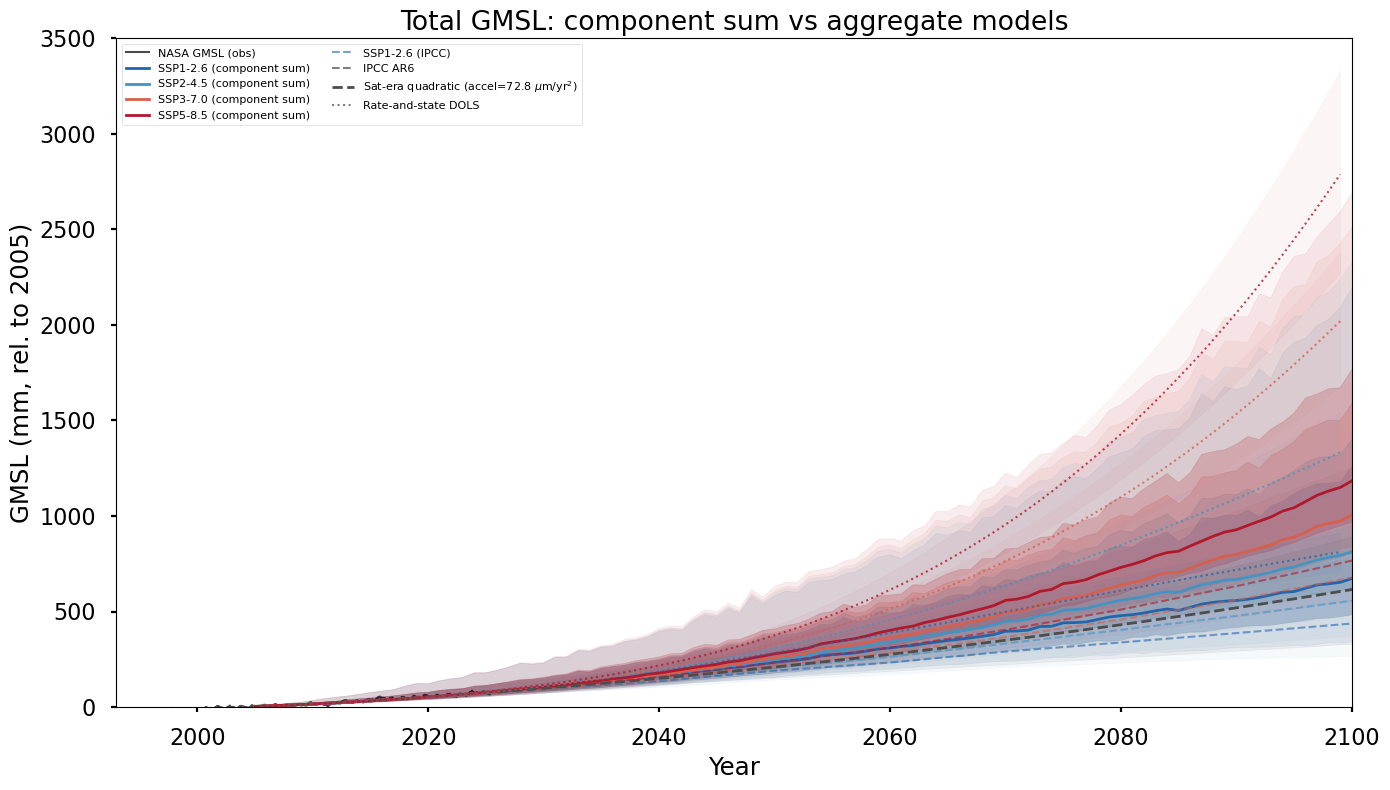

In [9]:
# ── Total GMSL projection: all SSPs + quad fit + rate-and-state ──

# ====== SWITCHES ======
SHOW_OBS        = True   # NASA GMSL observations
SHOW_QUAD       = True   # Satellite-era quadratic extrapolation
SHOW_RS         = True   # Rate-and-state DOLS
SHOW_IPCC       = True   # IPCC AR6 total projections
SHOW_COMP_SUM   = True   # Component sum
YEAR_END        = 2100   # right edge of x-axis
# ======================

proj_mask = proj_years >= 2005
yr_plot = proj_years[proj_mask]

fig, ax = plt.subplots(figsize=(14, 8))

# --- NASA GMSL observations ---
if SHOW_OBS:
    obs_mask = nasa_time >= 1993
    ax.plot(nasa_time[obs_mask], nasa_gmsl_rb[obs_mask] * M_TO_MM,
            'k-', lw=1.5, alpha=0.7, label='NASA GMSL (obs)')

# --- Component sum (per SSP) ---
if SHOW_COMP_SUM:
    for ssp in PROJ_SSPS:
        p = comp_projections[ssp]['Total_sum']
        med = p['median'][proj_mask] * M_TO_MM
        lo17 = p['p17'][proj_mask] * M_TO_MM
        hi83 = p['p83'][proj_mask] * M_TO_MM
        lo5 = p['p5'][proj_mask] * M_TO_MM
        hi95 = p['p95'][proj_mask] * M_TO_MM
        color = SSP_COLORS.get(ssp, 'gray')
        ax.plot(yr_plot, med, color=color, lw=2, label=f'{ssp} (component sum)')
        ax.fill_between(yr_plot, lo17, hi83, color=color, alpha=0.20)
        ax.fill_between(yr_plot, lo5, hi95, color=color, alpha=0.08)

# --- IPCC AR6 total ---
if SHOW_IPCC:
    for ssp in PROJ_SSPS:
        if ssp in ipcc_total:
            ie = ipcc_extract(ipcc_total[ssp])
            color = SSP_COLORS.get(ssp, 'gray')
            ax.plot(ie['years'], ie['q50'], color=color, lw=1.5, ls='--', alpha=0.6,
                    label=f'{ssp} (IPCC)' if ssp == PROJ_SSPS[0] else '')
            ax.fill_between(ie['years'], ie['q05'], ie['q95'],
                            color=color, alpha=0.04)
    ax.plot([], [], ls='--', color='0.5', lw=1.5, label='IPCC AR6')

# --- Satellite-era quadratic extrapolation ---
if SHOW_QUAD:
    sq_obs_mask = (sat_quad_time >= 2005) & (sat_quad_time <= nasa_time[-1])
    ax.plot(sat_quad_time[sq_obs_mask], sat_quad_fit_rb[sq_obs_mask] * M_TO_MM,
            '-', color='0.3', lw=1, alpha=0.6)
    sq_ext_mask = sat_quad_time >= nasa_time[-1]
    ax.plot(sat_quad_time[sq_ext_mask], sat_quad_fit_rb[sq_ext_mask] * M_TO_MM,
            '--', color='0.3', lw=2,
            label=f'Sat-era quadratic (accel={sat_quad.accel*1e6:.1f} $\\mu$m/yr$^2$)')
    ax.fill_between(sat_quad_time[sq_ext_mask],
                    sat_quad_p5[sq_ext_mask] * M_TO_MM,
                    sat_quad_p95[sq_ext_mask] * M_TO_MM,
                    color='0.3', alpha=0.08)

# --- Rate-and-state DOLS (per SSP) ---
if SHOW_RS:
    for ssp in PROJ_SSPS:
        rs_df = rs_results['scenarios'][ssp]
        rs_time = rs_df['decimal_year'].values
        mask_rs = (rs_time >= 2005) & (rs_time <= YEAR_END)
        color = SSP_COLORS.get(ssp, 'gray')
        ax.plot(rs_time[mask_rs], rs_df['gmsl'].values[mask_rs] * M_TO_MM,
                ':', color=color, lw=1.5, alpha=0.8)
        ax.fill_between(rs_time[mask_rs],
                        rs_df['gmsl_lower'].values[mask_rs] * M_TO_MM,
                        rs_df['gmsl_upper'].values[mask_rs] * M_TO_MM,
                        color=color, alpha=0.04)
    ax.plot([], [], ':', color='0.5', lw=1.5, label='Rate-and-state DOLS')

ax.set_ylim(0,3500)

ax.set_xlabel('Year')
ax.set_ylabel('GMSL (mm, rel. to 2005)')
ax.set_title('Total GMSL: component sum vs aggregate models')
ax.set_xlim(1993 if SHOW_OBS else 2005, YEAR_END)
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.legend(fontsize=8, loc='upper left', ncol=2)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_summation_total.png', dpi=150, bbox_inches='tight')
plt.show()

  IPCC excl. AIS SSP1-2.6 at 2100: 315 [140, 536] mm (Thermosteric, Glaciers, Greenland, TWS)
  IPCC excl. AIS SSP2-4.5 at 2100: 433 [240, 675] mm (Thermosteric, Glaciers, Greenland, TWS)
  IPCC excl. AIS SSP3-7.0 at 2100: 555 [340, 812] mm (Thermosteric, Glaciers, Greenland, TWS)
  IPCC excl. AIS SSP5-8.5 at 2100: 632 [404, 930] mm (Thermosteric, Glaciers, Greenland, TWS)


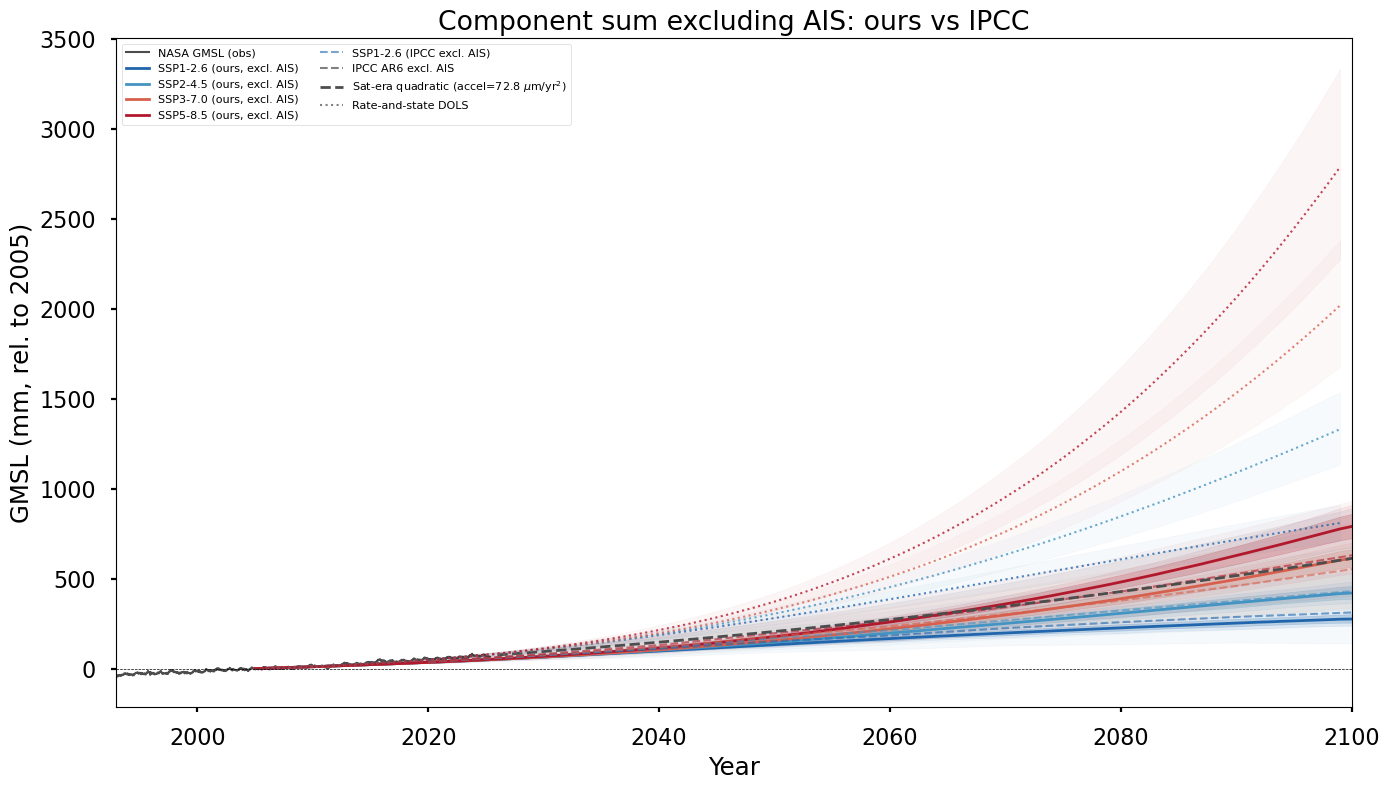

In [17]:
# ── Total GMSL excluding AIS: component-level comparison with IPCC ──
# Remove all Antarctic components (EAIS, WAIS, Peninsula) from both
# our sum and the IPCC sum for a like-for-like comparison.

# ====== SWITCHES ======
SHOW_OBS_NA     = True   # NASA GMSL observations
SHOW_QUAD_NA    = True   # Satellite-era quadratic extrapolation
SHOW_RS_NA      = True   # Rate-and-state DOLS
SHOW_IPCC_NA    = True   # IPCC component sum (excl. AIS)
SHOW_COMP_NA    = True   # Our component sum (excl. AIS)
YEAR_END_NA     = 2100   # right edge of x-axis
# ======================

ais_labels = {'EAIS', 'WAIS', 'Peninsula'}
comps_no_ais = [c for c in COMP_LABELS.values() if c not in ais_labels]

# Load IPCC components for like-for-like sum (excl. AIS)
ipcc_comp_map = {
    'oceandynamics': 'Thermosteric',
    'glaciers': 'Glaciers',
    'GIS': 'Greenland',
    'landwaterstorage': 'TWS',
}

ipcc_no_ais = {}  # {ssp: {'years': ..., 'q50': ..., 'q05': ..., 'q95': ...}}
for ssp, code in SSP_TO_CODE.items():
    comp_data = {}
    for ipcc_key, label in ipcc_comp_map.items():
        data = read_ipcc_component_nc(CONF_BASE, 'medium_confidence', code, ipcc_key)
        if data is not None:
            comp_data[label] = ipcc_extract(data)

    if not comp_data:
        continue

    # Sum on common year grid (use first component's years)
    ref_years = list(comp_data.values())[0]['years']
    q50_sum = np.zeros_like(ref_years, dtype=float)
    q05_sum = np.zeros_like(ref_years, dtype=float)
    q95_sum = np.zeros_like(ref_years, dtype=float)
    for label, ie in comp_data.items():
        q50_sum += np.interp(ref_years, ie['years'], ie['q50'])
        q05_sum += np.interp(ref_years, ie['years'], ie['q05'])
        q95_sum += np.interp(ref_years, ie['years'], ie['q95'])

    ipcc_no_ais[ssp] = {'years': ref_years, 'q50': q50_sum,
                         'q05': q05_sum, 'q95': q95_sum}

    idx_2100 = np.argmin(np.abs(ref_years - 2100))
    print(f'  IPCC excl. AIS {ssp} at 2100: {q50_sum[idx_2100]:.0f} '
          f'[{q05_sum[idx_2100]:.0f}, {q95_sum[idx_2100]:.0f}] mm '
          f'({", ".join(comp_data.keys())})')

fig, ax = plt.subplots(figsize=(14, 8))

# --- NASA GMSL observations ---
if SHOW_OBS_NA:
    obs_mask = nasa_time >= 1993
    ax.plot(nasa_time[obs_mask], nasa_gmsl_rb[obs_mask] * M_TO_MM,
            'k-', lw=1.5, alpha=0.7, label='NASA GMSL (obs)')

# --- Our component sum excluding AIS ---
if SHOW_COMP_NA:
    for ssp in PROJ_SSPS:
        total_no_ais = np.zeros_like(
            comp_projections[ssp]['Total_sum']['samples'])
        for cname in comps_no_ais:
            if cname in comp_projections[ssp]:
                total_no_ais += comp_projections[ssp][cname]['samples']

        med = np.median(total_no_ais, axis=0)[proj_mask] * M_TO_MM
        lo17 = np.percentile(total_no_ais, 17, axis=0)[proj_mask] * M_TO_MM
        hi83 = np.percentile(total_no_ais, 83, axis=0)[proj_mask] * M_TO_MM
        lo5 = np.percentile(total_no_ais, 5, axis=0)[proj_mask] * M_TO_MM
        hi95 = np.percentile(total_no_ais, 95, axis=0)[proj_mask] * M_TO_MM
        color = SSP_COLORS.get(ssp, 'gray')
        ax.plot(yr_plot, med, color=color, lw=2, label=f'{ssp} (ours, excl. AIS)')
        ax.fill_between(yr_plot, lo17, hi83, color=color, alpha=0.20)
        ax.fill_between(yr_plot, lo5, hi95, color=color, alpha=0.08)

# --- IPCC component sum excluding AIS ---
if SHOW_IPCC_NA:
    for ssp in PROJ_SSPS:
        if ssp in ipcc_no_ais:
            d = ipcc_no_ais[ssp]
            color = SSP_COLORS.get(ssp, 'gray')
            ax.plot(d['years'], d['q50'], color=color, lw=1.5, ls='--', alpha=0.6,
                    label=f'{ssp} (IPCC excl. AIS)' if ssp == PROJ_SSPS[0] else '')
            ax.fill_between(d['years'], d['q05'], d['q95'],
                            color=color, alpha=0.04)
    ax.plot([], [], ls='--', color='0.5', lw=1.5, label='IPCC AR6 excl. AIS')

# --- Satellite-era quadratic extrapolation ---
if SHOW_QUAD_NA:
    sq_obs_mask = (sat_quad_time >= 2005) & (sat_quad_time <= nasa_time[-1])
    ax.plot(sat_quad_time[sq_obs_mask], sat_quad_fit_rb[sq_obs_mask] * M_TO_MM,
            '-', color='0.3', lw=1, alpha=0.6)
    sq_ext_mask = sat_quad_time >= nasa_time[-1]
    ax.plot(sat_quad_time[sq_ext_mask], sat_quad_fit_rb[sq_ext_mask] * M_TO_MM,
            '--', color='0.3', lw=2,
            label=f'Sat-era quadratic (accel={sat_quad.accel*1e6:.1f} $\\mu$m/yr$^2$)')
    ax.fill_between(sat_quad_time[sq_ext_mask],
                    sat_quad_p5[sq_ext_mask] * M_TO_MM,
                    sat_quad_p95[sq_ext_mask] * M_TO_MM,
                    color='0.3', alpha=0.08)

# --- Rate-and-state DOLS ---
if SHOW_RS_NA:
    for ssp in PROJ_SSPS:
        rs_df = rs_results['scenarios'][ssp]
        rs_time = rs_df['decimal_year'].values
        mask_rs = (rs_time >= 2005) & (rs_time <= YEAR_END_NA)
        color = SSP_COLORS.get(ssp, 'gray')
        ax.plot(rs_time[mask_rs], rs_df['gmsl'].values[mask_rs] * M_TO_MM,
                ':', color=color, lw=1.5, alpha=0.8)
        ax.fill_between(rs_time[mask_rs],
                        rs_df['gmsl_lower'].values[mask_rs] * M_TO_MM,
                        rs_df['gmsl_upper'].values[mask_rs] * M_TO_MM,
                        color=color, alpha=0.04)
    ax.plot([], [], ':', color='0.5', lw=1.5, label='Rate-and-state DOLS')

ax.set_xlabel('Year')
ax.set_ylabel('GMSL (mm, rel. to 2005)')
ax.set_title('Component sum excluding AIS: ours vs IPCC')
ax.set_xlim(1993 if SHOW_OBS_NA else 2005, YEAR_END_NA)
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.legend(fontsize=8, loc='upper left', ncol=2)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_summation_no_ais.png', dpi=150, bbox_inches='tight')
plt.show()

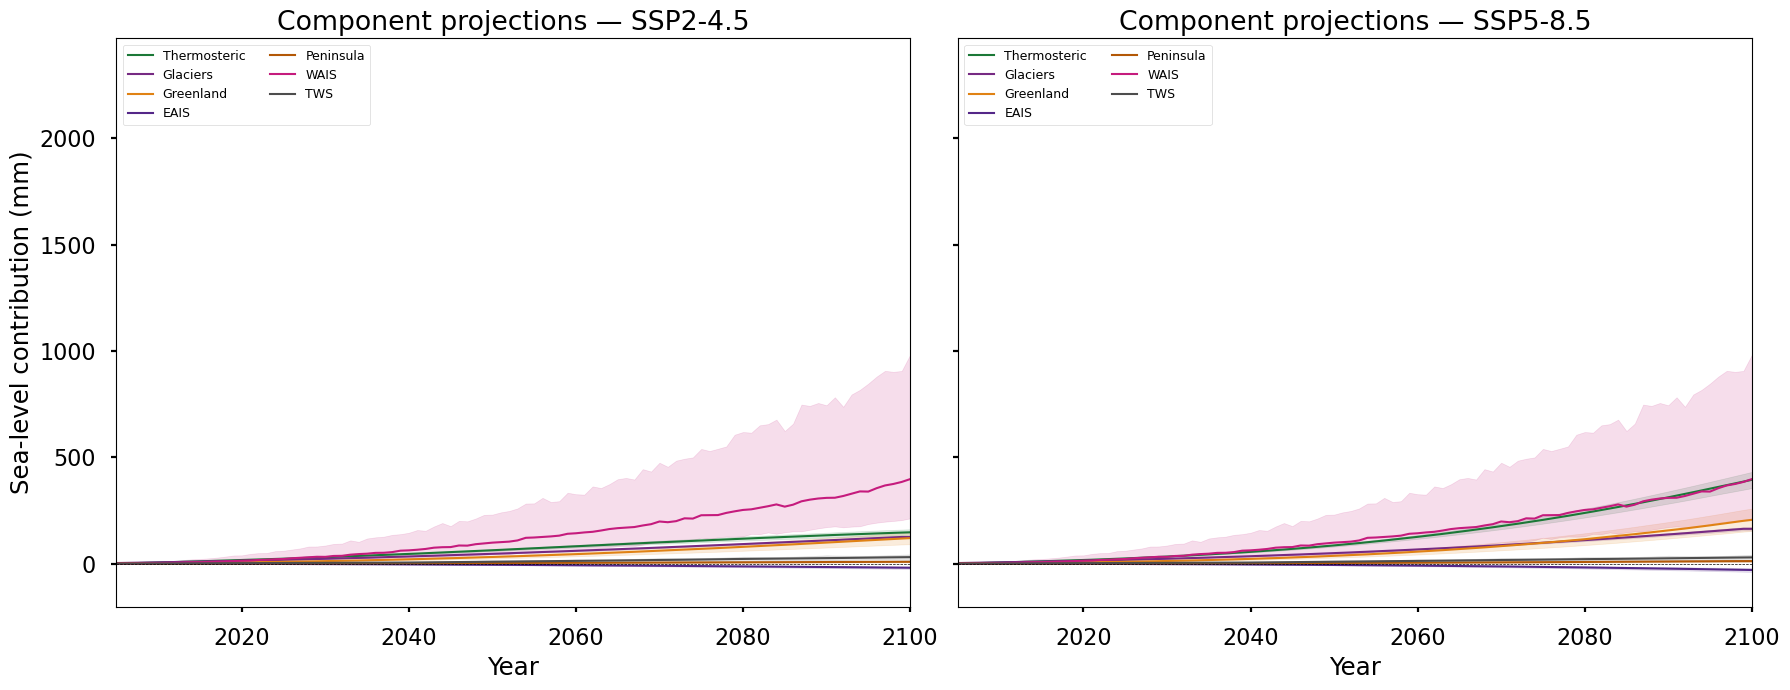

In [11]:
# ── Per-component fans for SSP2-4.5 and SSP5-8.5 ──
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

for ax, ssp in zip(axes, ['SSP2-4.5', 'SSP5-8.5']):
    for cname in comp_order:
        if cname not in comp_projections[ssp]:
            continue
        p = comp_projections[ssp][cname]
        med = p['median'][proj_mask] * M_TO_MM
        lo = p['p17'][proj_mask] * M_TO_MM
        hi = p['p83'][proj_mask] * M_TO_MM
        color = COMP_COLORS.get(cname, 'gray')
        ax.plot(yr_plot, med, color=color, lw=1.5, label=cname)
        ax.fill_between(yr_plot, lo, hi, color=color, alpha=0.15)

    ax.set_xlabel('Year')
    ax.set_title(f'Component projections — {ssp}')
    ax.set_xlim(2005, 2100)
    ax.axhline(0, color='k', lw=0.5, ls='--')
    ax.legend(fontsize=9, loc='upper left', ncol=2)

axes[0].set_ylabel('Sea-level contribution (mm)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_summation_fans.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Component Stack & Variance Decomposition

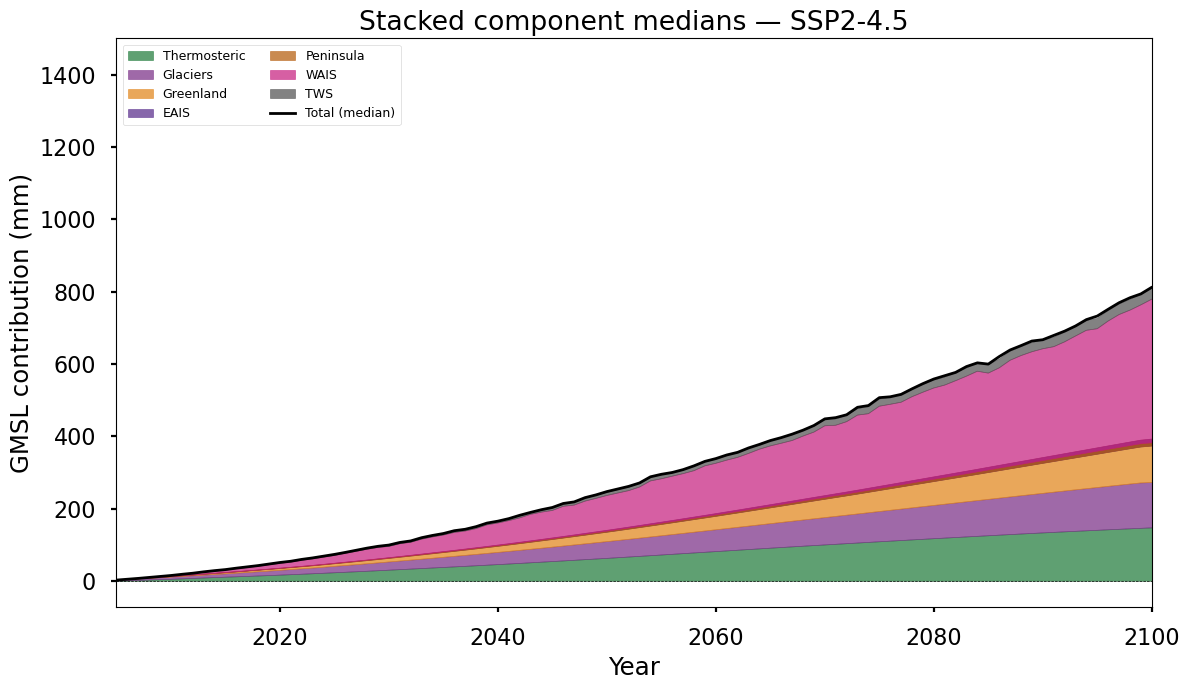

In [12]:
# ── Stacked median contributions (SSP2-4.5) ──
ssp_show = 'SSP2-4.5'
fig, ax = plt.subplots(figsize=(12, 7))

bottoms = np.zeros(proj_mask.sum())
for cname in comp_order:
    if cname not in comp_projections[ssp_show]:
        continue
    med = comp_projections[ssp_show][cname]['median'][proj_mask] * M_TO_MM
    color = COMP_COLORS.get(cname, 'gray')
    ax.fill_between(yr_plot, bottoms, bottoms + med, color=color, alpha=0.7, label=cname)
    bottoms += med

# Overlay total median
tot_med = comp_projections[ssp_show]['Total_sum']['median'][proj_mask] * M_TO_MM
ax.plot(yr_plot, tot_med, 'k-', lw=2, label='Total (median)')

ax.set_xlabel('Year')
ax.set_ylabel('GMSL contribution (mm)')
ax.set_title(f'Stacked component medians — {ssp_show}')
ax.set_xlim(2005, 2100)
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.legend(loc='upper left', fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_summation_stacked.png', dpi=150, bbox_inches='tight')
plt.show()

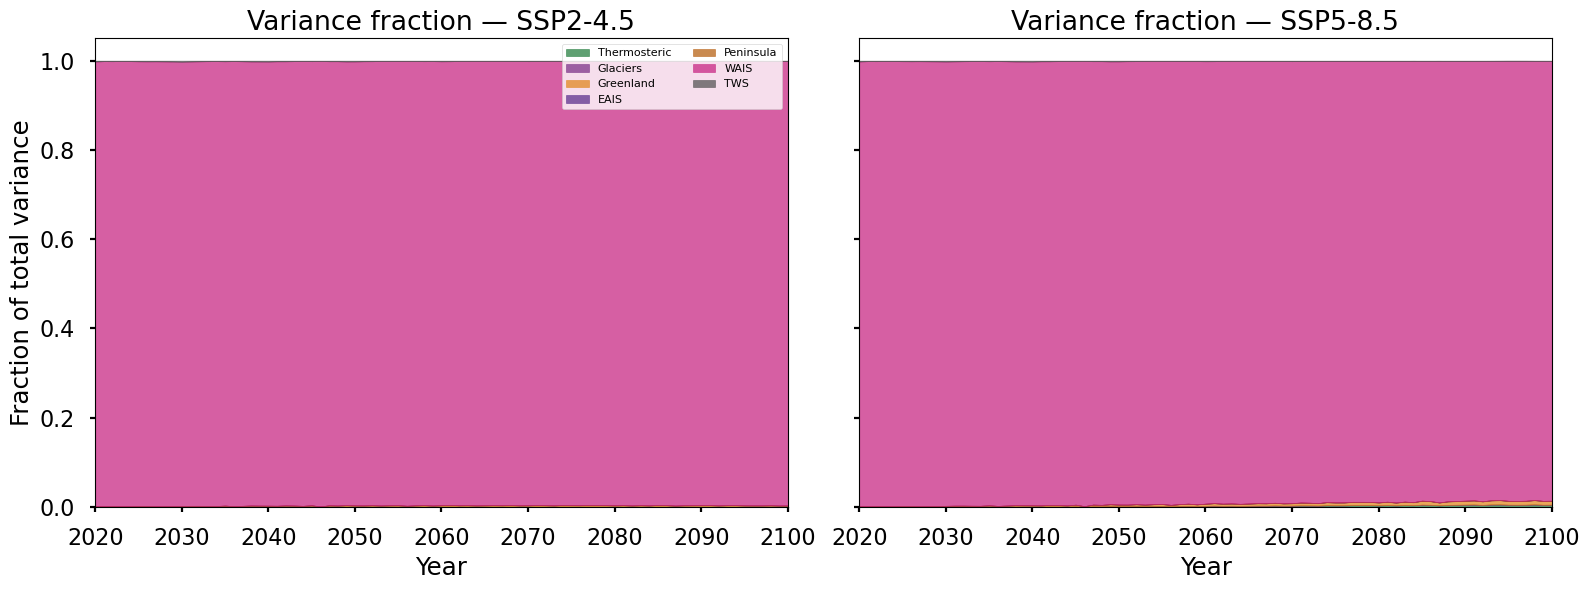

In [13]:
# ── Variance decomposition ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, ssp in zip(axes, ['SSP2-4.5', 'SSP5-8.5']):
    comps_available = [c for c in comp_order if c in comp_projections[ssp]]
    fracs, raw_sum = compute_variance_fractions(
        ssp, comps_available, proj_years, comp_projections,
    )
    proj_mask_var = proj_years >= 2020
    yr_var = proj_years[proj_mask_var]

    bottoms = np.zeros(proj_mask_var.sum())
    for cname in comps_available:
        f = fracs[cname][proj_mask_var]
        color = COMP_COLORS.get(cname, 'gray')
        ax.fill_between(yr_var, bottoms, bottoms + f, color=color, alpha=0.7, label=cname)
        bottoms += f

    ax.set_xlim(2020, 2100)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel('Year')
    ax.set_title(f'Variance fraction — {ssp}')

axes[0].set_ylabel('Fraction of total variance')
axes[0].legend(fontsize=8, loc='upper right', ncol=2)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_summation_variance.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. IPCC AR6 Comparison

In [14]:
# IPCC total already loaded in cell 10 — print summary
for ssp in sorted(ipcc_total.keys()):
    data = ipcc_total[ssp]
    print(f'  {ssp}: {data["years"][0]:.0f}–{data["years"][-1]:.0f}, '
          f'{len(data["quantiles"])} quantiles')

  SSP1-2.6: 2020–2150, 107 quantiles
  SSP2-4.5: 2020–2150, 107 quantiles
  SSP3-7.0: 2020–2150, 107 quantiles
  SSP5-8.5: 2020–2150, 107 quantiles


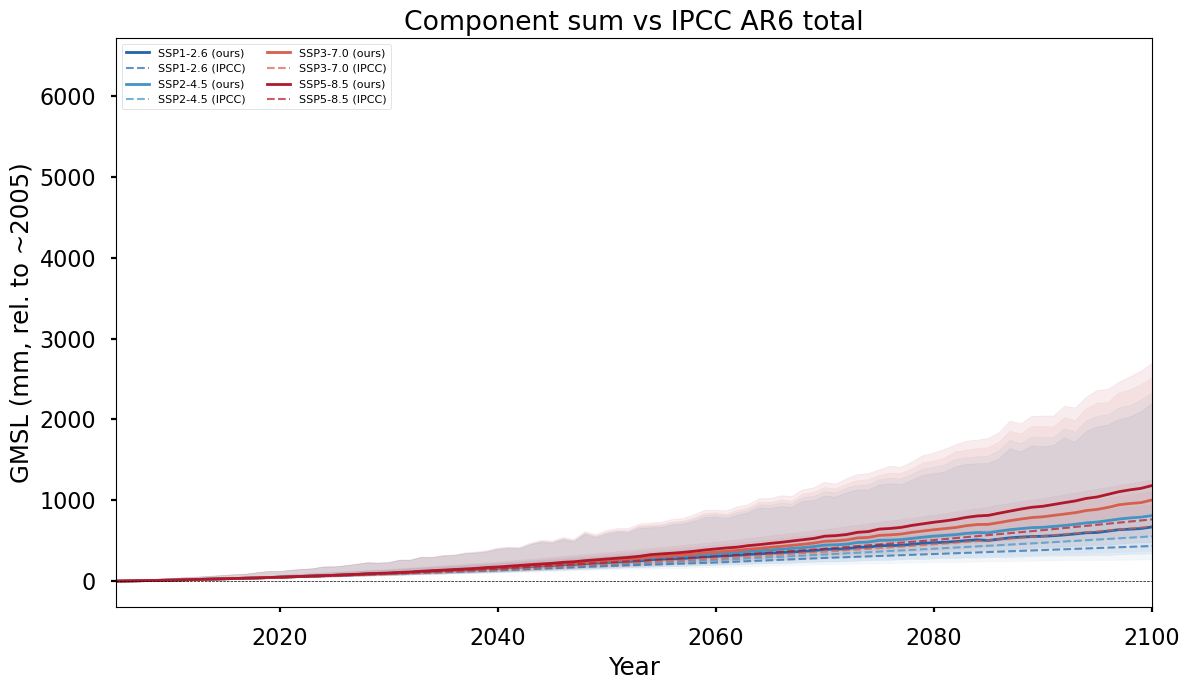

In [15]:
# ── Our total vs IPCC total ──
fig, ax = plt.subplots(figsize=(12, 7))

for ssp in PROJ_SSPS:
    color = SSP_COLORS.get(ssp, 'gray')

    # Our projection
    p = comp_projections[ssp]['Total_sum']
    med = p['median'][proj_mask] * M_TO_MM
    lo = p['p5'][proj_mask] * M_TO_MM
    hi = p['p95'][proj_mask] * M_TO_MM
    ax.plot(yr_plot, med, color=color, lw=2, label=f'{ssp} (ours)')
    ax.fill_between(yr_plot, lo, hi, color=color, alpha=0.08)

    # IPCC
    if ssp in ipcc_total:
        ipcc_d = ipcc_total[ssp]
        ie = ipcc_extract(ipcc_d)
        ax.plot(ie['years'], ie['q50'], color=color, lw=1.5, ls='--', alpha=0.7,
                label=f'{ssp} (IPCC)')
        ax.fill_between(ie['years'], ie['q05'], ie['q95'],
                         color=color, alpha=0.05, linestyle='--')

ax.set_xlabel('Year')
ax.set_ylabel('GMSL (mm, rel. to ~2005)')
ax.set_title('Component sum vs IPCC AR6 total')
ax.set_xlim(2005, 2100)
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.legend(fontsize=8, loc='upper left', ncol=2)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_summation_vs_ipcc.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# ── Numerical comparison at 2100 ──
print(f'{"SSP":<12} {"Ours (median [5,95])":<30} {"IPCC (median [5,95])":<30}')
print('-' * 72)
for ssp in PROJ_SSPS:
    idx_2100 = np.argmin(np.abs(proj_years - 2100))
    s = comp_projections[ssp]['Total_sum']['samples'][:, idx_2100] * M_TO_MM
    ours_str = f'{np.median(s):.0f} [{np.percentile(s, 5):.0f}, {np.percentile(s, 95):.0f}]'

    if ssp in ipcc_total:
        ipcc_stats = get_ipcc_stats(
            {ssp: {'total': ipcc_total[ssp]}}, ssp, 'total', year=2100,
        )
        if ipcc_stats is not None:
            ipcc_str = f'{ipcc_stats[1]:.0f} [{ipcc_stats[0]:.0f}, {ipcc_stats[2]:.0f}]'
        else:
            ipcc_str = '—'
    else:
        ipcc_str = '—'

    print(f'{ssp:<12} {ours_str:<30} {ipcc_str:<30}')

SSP          Ours (median [5,95])           IPCC (median [5,95])          
------------------------------------------------------------------------
SSP1-2.6     672 [342, 2193]                437 [265, 775]                
SSP2-4.5     812 [483, 2325]                556 [371, 946]                
SSP3-7.0     1005 [669, 2511]               678 [480, 1105]               
SSP5-8.5     1183 [839, 2689]               766 [555, 1252]               
